In [1]:
from Bio import SeqIO
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import pairwise2
from Bio.Seq import  Seq
from Bio.Align import PairwiseAligner

In [2]:
file_path = r'E:\pUGTdb\pUGTdb_completeUGTs.pep'

In [3]:
with open(file_path, 'rb') as f:
    raw_data = f.read()

In [4]:
# 存储序列信息的列表
sequences_data = []
# 解析FASTA文件
for record in SeqIO.parse(file_path, "fasta"):
    sequences_data.append({
        'name': record.description,      # 序列名称
        'sequence': str(record.seq)  # 序列内容
    })
# 创建DataFrame
df = pd.DataFrame(sequences_data)

In [5]:
df

,name,sequence
0,TXG46902.1 hypothetical protein EZV62_026196 [...,MGKPHVVCIPYPAQGHIKPMLNVAKLLHSKGFHITFVNTEYNHKRL...
1,TXG46911.1 hypothetical protein EZV62_026205 [...,MGKPHVVCIPYPAQGHIKPMLNVAKLLHSKGFHITFVNTEYNHKRL...
2,TXG47487.1 hypothetical protein EZV62_026781 [...,METKVVASNLRLSKVSCQKKKRVAMGEKKLHIAMYPWLAMSHLNAF...
3,TXG47488.1 hypothetical protein EZV62_026782 [...,MEEKSLHIAMYPWFAMSHLNAFLQLSNKLAERGHRVSFLLPEKTQA...
4,TXG47490.1 hypothetical protein EZV62_026784 [...,MEEKSLHIAMYPWFAMSHLNAFLQLSNKLAERGHRVSFLLPEKTQA...
...,...,...
228582,XP_030973956.1 [Quercus lobata],MLKHQQNQFVIVTYPLQGHINPAFQFAERLIRLGVHVTFFTAIGAH...
228583,XP_030975687.1 [Quercus lobata],MDSKQERSNSISILMLPWLAHGHISPFLDLARKLSLRNFHVYFCST...
228584,XP_024024627.1 [Morus notabilis],MEEIRREKGTHILVIPYPVQGHINPMLQFSKRLASKNRRLIRITLL...
228585,XP_024029391.1 [Morus notabilis],MGSNGDDHHPMKHLDHHPMKHLEESVNHFDQQSGGGGGDNNSGNEQ...


In [8]:
def clean_sequence_str(seq):
    """移除空白符，转大写，移除末尾的*"""
    if not isinstance(seq, str): return ""
    seq = seq.strip().upper()
    if seq.endswith('*') or seq.endswith('.'):  #因为最后一个*是代表终止密码子，就是翻译完了，并不是错误序列
        seq = seq[:-1]
    return seq

def is_valid_sequence(seq):
    """检查是否只包含 20 种标准氨基酸"""
    standard_aa = set("ACDEFGHIKLMNPQRSTVWY")
    if len(seq) == 0: return False
    return all(char in standard_aa for char in seq)

# ID前缀分析
def extract_id_prefix(name):
    # 提取ID并获取前缀部分
    id_match = re.match(r'^([a-zA-Z]+)', name)
    return id_match.group(1) if id_match else 'Unknown'


# Step 1: 基础字符清洗
df['clean_seq'] = df['sequence'].apply(clean_sequence_str)
# Step 2: 剔除含非法字符的序列 (X, B, Z, J, *, 等)
valid_mask = df['clean_seq'].apply(is_valid_sequence)
df_valid_char = df[valid_mask].copy()
# Step 3: 剔除ID的尾缀是T的序列（可能是转录本，置信度低），同时，提出R和A前缀的序列，可能是 PDB 链（Chain A）或者棉花 A 亚基因组；可能是 RefSeq 简写或 Repeat
df_valid_char['id_prefix'] = df_valid_char['name'].apply(extract_id_prefix)
df_filtered = df_valid_char[~df_valid_char['id_prefix'].str.endswith('T')]
df_filtered = df_filtered[~df_filtered['id_prefix'].isin(['R', 'A'])]  #
# Step 4: 获取序列长度,并且进行筛选
df_filtered['length'] = df_filtered['clean_seq'].str.len()
df_filtered = df_filtered[(df_filtered['length'] < 600) & (df_filtered['length'] > 350)]

In [15]:
df_filtered

,name,sequence,clean_seq,id_prefix,length
0,TXG46902.1 hypothetical protein EZV62_026196 [...,MGKPHVVCIPYPAQGHIKPMLNVAKLLHSKGFHITFVNTEYNHKRL...,MGKPHVVCIPYPAQGHIKPMLNVAKLLHSKGFHITFVNTEYNHKRL...,TXG,442
1,TXG46911.1 hypothetical protein EZV62_026205 [...,MGKPHVVCIPYPAQGHIKPMLNVAKLLHSKGFHITFVNTEYNHKRL...,MGKPHVVCIPYPAQGHIKPMLNVAKLLHSKGFHITFVNTEYNHKRL...,TXG,475
2,TXG47487.1 hypothetical protein EZV62_026781 [...,METKVVASNLRLSKVSCQKKKRVAMGEKKLHIAMYPWLAMSHLNAF...,METKVVASNLRLSKVSCQKKKRVAMGEKKLHIAMYPWLAMSHLNAF...,TXG,481
3,TXG47488.1 hypothetical protein EZV62_026782 [...,MEEKSLHIAMYPWFAMSHLNAFLQLSNKLAERGHRVSFLLPEKTQA...,MEEKSLHIAMYPWFAMSHLNAFLQLSNKLAERGHRVSFLLPEKTQA...,TXG,456
4,TXG47490.1 hypothetical protein EZV62_026784 [...,MEEKSLHIAMYPWFAMSHLNAFLQLSNKLAERGHRVSFLLPEKTQA...,MEEKSLHIAMYPWFAMSHLNAFLQLSNKLAERGHRVSFLLPEKTQA...,TXG,456
...,...,...,...,...,...
228580,XP_030973621.1 [Quercus lobata],MNSMAERKKLHIAMFPWLAFGHIIPFLELSKLIAQKGHRISFISTP...,MNSMAERKKLHIAMFPWLAFGHIIPFLELSKLIAQKGHRISFISTP...,XP,468
228582,XP_030973956.1 [Quercus lobata],MLKHQQNQFVIVTYPLQGHINPAFQFAERLIRLGVHVTFFTAIGAH...,MLKHQQNQFVIVTYPLQGHINPAFQFAERLIRLGVHVTFFTAIGAH...,XP,394
228583,XP_030975687.1 [Quercus lobata],MDSKQERSNSISILMLPWLAHGHISPFLDLARKLSLRNFHVYFCST...,MDSKQERSNSISILMLPWLAHGHISPFLDLARKLSLRNFHVYFCST...,XP,457
228584,XP_024024627.1 [Morus notabilis],MEEIRREKGTHILVIPYPVQGHINPMLQFSKRLASKNRRLIRITLL...,MEEIRREKGTHILVIPYPVQGHINPMLQFSKRLASKNRRLIRITLL...,XP,461


In [16]:
df_filtered

(166650, 5)

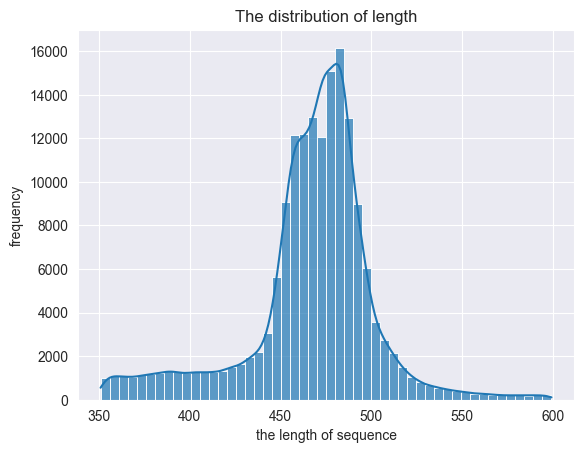

In [18]:
# 绘制带密度曲线的直方图
sns.histplot(df_filtered['length'], bins=50, kde=True, alpha=0.7)
plt.xlabel("the length of sequence")
plt.ylabel('frequency')
plt.title('The distribution of length')
plt.show()


In [19]:
df_filtered

,name,sequence,clean_seq,id_prefix,length
0,TXG46902.1 hypothetical protein EZV62_026196 [...,MGKPHVVCIPYPAQGHIKPMLNVAKLLHSKGFHITFVNTEYNHKRL...,MGKPHVVCIPYPAQGHIKPMLNVAKLLHSKGFHITFVNTEYNHKRL...,TXG,442
1,TXG46911.1 hypothetical protein EZV62_026205 [...,MGKPHVVCIPYPAQGHIKPMLNVAKLLHSKGFHITFVNTEYNHKRL...,MGKPHVVCIPYPAQGHIKPMLNVAKLLHSKGFHITFVNTEYNHKRL...,TXG,475
2,TXG47487.1 hypothetical protein EZV62_026781 [...,METKVVASNLRLSKVSCQKKKRVAMGEKKLHIAMYPWLAMSHLNAF...,METKVVASNLRLSKVSCQKKKRVAMGEKKLHIAMYPWLAMSHLNAF...,TXG,481
3,TXG47488.1 hypothetical protein EZV62_026782 [...,MEEKSLHIAMYPWFAMSHLNAFLQLSNKLAERGHRVSFLLPEKTQA...,MEEKSLHIAMYPWFAMSHLNAFLQLSNKLAERGHRVSFLLPEKTQA...,TXG,456
4,TXG47490.1 hypothetical protein EZV62_026784 [...,MEEKSLHIAMYPWFAMSHLNAFLQLSNKLAERGHRVSFLLPEKTQA...,MEEKSLHIAMYPWFAMSHLNAFLQLSNKLAERGHRVSFLLPEKTQA...,TXG,456
...,...,...,...,...,...
228580,XP_030973621.1 [Quercus lobata],MNSMAERKKLHIAMFPWLAFGHIIPFLELSKLIAQKGHRISFISTP...,MNSMAERKKLHIAMFPWLAFGHIIPFLELSKLIAQKGHRISFISTP...,XP,468
228582,XP_030973956.1 [Quercus lobata],MLKHQQNQFVIVTYPLQGHINPAFQFAERLIRLGVHVTFFTAIGAH...,MLKHQQNQFVIVTYPLQGHINPAFQFAERLIRLGVHVTFFTAIGAH...,XP,394
228583,XP_030975687.1 [Quercus lobata],MDSKQERSNSISILMLPWLAHGHISPFLDLARKLSLRNFHVYFCST...,MDSKQERSNSISILMLPWLAHGHISPFLDLARKLSLRNFHVYFCST...,XP,457
228584,XP_024024627.1 [Morus notabilis],MEEIRREKGTHILVIPYPVQGHINPMLQFSKRLASKNRRLIRITLL...,MEEIRREKGTHILVIPYPVQGHINPMLQFSKRLASKNRRLIRITLL...,XP,461


In [20]:
csv_file_path = r'E:\pUGTdb\pUGTdb_completeUGTs_QC.csv'
df_filtered.to_csv(csv_file_path, index=False)
